In [1]:
%pylab inline
import astropy.units as u
from astropy.cosmology import Planck15
import matplotlib.colors as colors
from scipy.optimize import curve_fit
import scipy.integrate as integrate
import numpy.random
from numpy.linalg import det
from mpl_toolkits import mplot3d

sys.path.insert(0, "../bin")
import matplotlib.ticker as ticker

plt.rc('font', family='serif')
mpl.rcParams['ytick.labelsize'] = 24
mpl.rcParams['xtick.labelsize'] = 24
mpl.rcParams['axes.labelsize'] = 34
mpl.rcParams['legend.fontsize'] = 24
def fmt(x, pos):
    a, b = '{:.1e}'.format(x).split('e')
    b = int(b)
    return r'${}\!\times 10^{{{}}}$'.format(a, b)

Populating the interactive namespace from numpy and matplotlib


In [63]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import healpy as hp
import warnings
warnings.filterwarnings('ignore')


In [64]:
earthMap = hp.read_map("CMBEarth/etopo5_hp.fits")
nside = hp.pixelfunc.get_nside(earthMap)

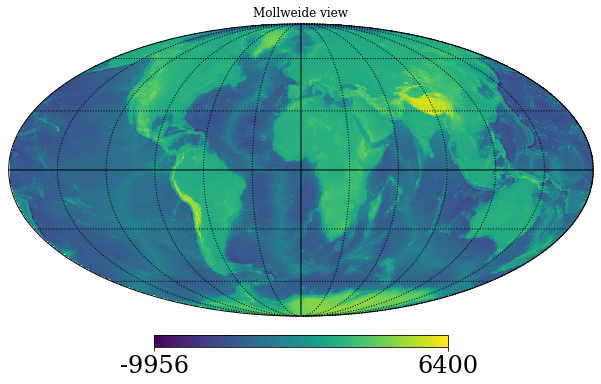

In [65]:
hp.mollview(earthMap)
hp.graticule()

In [72]:
LMAX = 1024
cl = hp.anafast(earthMap, lmax=LMAX)
ell = np.arange(len(cl))

1448.1546878700499


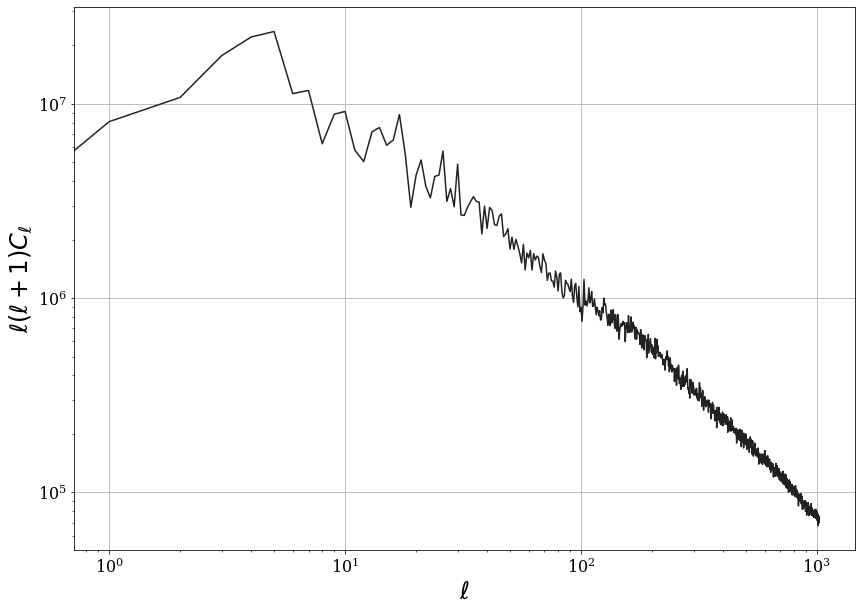

In [80]:
fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(111)

ax.plot(ell, ell * (ell + 1) * cl, c="#222222", lw=1.5, label="Press-Schechter")

#ax.axvline(x=1.83812910128e+14)
ax.set_xscale("log")
ax.set_xlabel(r"$\ell$", size=24)
ax.set_yscale("log")
ax.set_ylabel(r"$\ell(\ell+1)C_{\ell}$", size=24)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.grid(True)
plt.savefig("/media/data/documents/Uni/PhD/Thesis/tex/fig/hmf.pdf",bbox_inches='tight')


In [8]:
begin = 9
clNew = cl.copy()
#clNew[begin:] = 0

/home/schwinn/anaconda3/lib/python3.8/site-packages/healpy/sphtfunc.py:433: FutureChangeWarning: The order of the input cl's will change in a future release.
Use new=True keyword to start using the new order.
See documentation of healpy.synalm.
  warnings.warn(
/home/schwinn/anaconda3/lib/python3.8/site-packages/healpy/sphtfunc.py:822: UserWarning: Sigma is 0.000000 arcmin (0.000000 rad) 
  warnings.warn(
/home/schwinn/anaconda3/lib/python3.8/site-packages/healpy/sphtfunc.py:827: UserWarning: -> fwhm is 0.000000 arcmin
  warnings.warn(
/home/schwinn/anaconda3/lib/python3.8/site-packages/healpy/projaxes.py:920: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("viridis"))
  newcm.set_over(newcm(1.0))
/home/schwinn/anaconda3/lib/python3.8/site-packages/healpy/projax

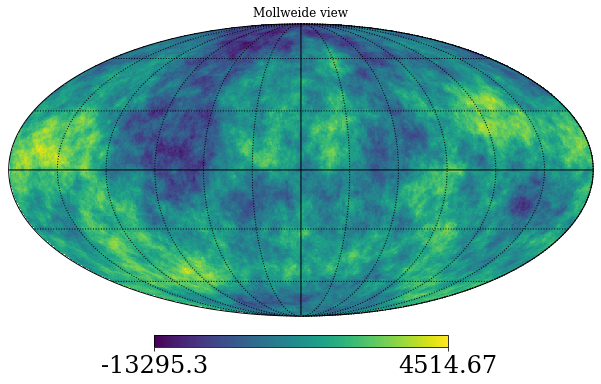

In [9]:
mapReconstr = hp.synfast(clNew, nside)
hp.mollview(mapReconstr)
hp.graticule()

### 2) $a_{\ell m}$

In [113]:
def plotAlmMap (LMAX):
    alm = hp.map2alm(earthMap,lmax=LMAX)
    mapReconstr = hp.alm2map(alm, nside,lmax=LMAX)
    hp.mollview(mapReconstr)
    hp.graticule()
    
    
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)

    
    ellLeq = ell[ell<=LMAX]
    clDimlessLeq = ellLeq* (ellLeq + 1) * cl[ell<=LMAX]
    
    ellGeq = ell[ell>=LMAX]
    clDimlessGeq = ellGeq * (ellGeq + 1) * cl[ell>=LMAX]
    
    ax.plot(ellLeq, clDimlessLeq, c="#222222", lw=1.5)
    ax.plot(ellGeq, clDimlessGeq, c="#666666", lw=1.5)
    
    ax.axvline(x=LMAX,lw=2)
    xLim = np.array(ax.get_xlim())    
    xLim[1] = 210
    ax.axvspan(LMAX, xLim[1], facecolor='0.2', alpha=0.2)
    #ax.axvline(x=1.83812910128e+14)
    ax.set_xscale("log")
    ax.set_xlim(xLim)
    ax.set_xlabel(r"$\ell$", size=24)
    ax.set_yscale("log")
    ax.set_ylabel(r"$\ell(\ell+1)C_{\ell}$", size=24)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    ax.grid(True)


In [115]:
widgets.interact(plotAlmMap, LMAX=(1, 200, 20))

interactive(children=(IntSlider(value=81, description='LMAX', max=200, min=1, step=20), Output()), _dom_classe…

<function __main__.plotAlmMap(LMAX)>

### 

### Stuff

NSIDE = 32
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)

NPIX = hp.nside2npix(NSIDE)
print(NPIX)

m = np.arange(NPIX)
hp.mollview(m, title="Mollview image RING")
hp.graticule()

vec = hp.ang2vec(np.pi / 2, np.pi * 3 / 4)
print(vec)
ipix_disc = hp.query_disc(nside=32, vec=vec, radius=np.radians(10))

m = np.arange(NPIX)
m[ipix_disc] = m.max()
hp.mollview(m, title="Mollview image RING")

In [9]:
mask = hp.read_map("wmap_temperature_analysis_mask_r9_7yr_v4.fits").astype(np.bool)
wmap_map_I_masked = hp.ma(wmap_map_I)
wmap_map_I_masked.mask = np.logical_not(mask)


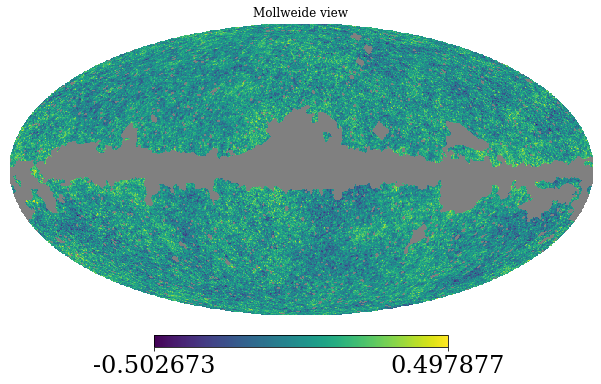

In [10]:
hp.mollview(wmap_map_I_masked.filled())